In [3]:

%config IPCompleter.greedy=True
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, split, when, lit, expr
from pyspark.sql.functions import monotonically_increasing_id
from functools import reduce
from pyspark.sql import DataFrame
import os
from datetime import datetime 
import matplotlib.pyplot as plt
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, StringType, StructField, FloatType, IntegerType, StructType
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.recommendation import ALS
import pandas as pd
from datetime import datetime
from pyspark.sql import functions as F
from pyspark.ml.linalg import Vectors, VectorUDT
import numpy as np

In [4]:
# Spark oturumunu başlat
spark = SparkSession.builder \
    .appName("MovieLens Analysis") \
    .getOrCreate()

In [5]:

# Görselleştirme için ayarları yapalım
%matplotlib inline
pd.set_option('display.max_columns', 100)

In [6]:
# Veri dosyalarının bulunduğu dizini belirtelim
BASE_PATH = "C:/spark/bin/Project"


In [7]:
# Her bir dosya için tam yolu belirtelim
credits_path = os.path.join(BASE_PATH, "credits.csv")
movies_metadata_path = os.path.join(BASE_PATH, "movies_metadata.csv")
keywords_path = os.path.join(BASE_PATH, "keywords.csv")
links_small_path = os.path.join(BASE_PATH, "links_small.csv")
ratings_small_path = os.path.join(BASE_PATH, "ratings_small.csv")

In [8]:
# Verileri Spark DataFrame olarak yükleyelim
credits_df = spark.read.csv(credits_path, header=True, inferSchema=True)
movies_metadata_df = spark.read.csv(movies_metadata_path, header=True, inferSchema=True)
keywords_df = spark.read.csv(keywords_path, header=True, inferSchema=True)
links_df = spark.read.csv(links_small_path, header=True, inferSchema=True)
ratings_df = spark.read.csv(ratings_small_path, header=True, inferSchema=True)

In [9]:
 #Veri boyutlarını ekrana yazdıralım
print("Ratings verisi {} satır ve {} sütun içeriyor".format(ratings_df.count(), len(ratings_df.columns)))
print("Links verisi {} satır ve {} sütun içeriyor".format(links_df.count(), len(links_df.columns)))
print("Movie metadata verisi {} satır ve {} sütun içeriyor".format(movies_metadata_df.count(), len(movies_metadata_df.columns)))
print("Credits verisi {} satır ve {} sütun içeriyor".format(credits_df.count(), len(credits_df.columns)))
print("Keywords verisi {} satır ve {} sütun içeriyor".format(keywords_df.count(), len(keywords_df.columns)))

Ratings verisi 100004 satır ve 4 sütun içeriyor
Links verisi 9125 satır ve 3 sütun içeriyor
Movie metadata verisi 45572 satır ve 24 sütun içeriyor
Credits verisi 45476 satır ve 3 sütun içeriyor
Keywords verisi 46419 satır ve 2 sütun içeriyor


In [10]:

# Veri tiplerini kontrol etme
ratings_df.printSchema()

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)



In [11]:

# movies_metadata_df'in sütunlarının veri tiplerini içeren bir schema oluşturma
schema = StructType([
    StructField("feature", StringType(), True),
    StructField("dtype", StringType(), True)
])

# movies_metadata_df sütunlarını ve veri tiplerini içeren bir DataFrame oluşturma
schema_df = spark.createDataFrame(
    [(feature, str(dtype)) for feature, dtype in movies_metadata_df.dtypes],
    schema
)

# Sonuçları gösterme
schema_df.show(truncate=False)

+---------------------+------+
|feature              |dtype |
+---------------------+------+
|adult                |string|
|belongs_to_collection|string|
|budget               |string|
|genres               |string|
|homepage             |string|
|id                   |string|
|imdb_id              |string|
|original_language    |string|
|original_title       |string|
|overview             |string|
|popularity           |string|
|poster_path          |string|
|production_companies |string|
|production_countries |string|
|release_date         |string|
|revenue              |string|
|runtime              |string|
|spoken_languages     |string|
|status               |string|
|tagline              |string|
+---------------------+------+
only showing top 20 rows



In [12]:
# Tanımlayıcı istatistikler
ratings_df.describe().show()

+-------+------------------+------------------+------------------+--------------------+
|summary|            userId|           movieId|            rating|           timestamp|
+-------+------------------+------------------+------------------+--------------------+
|  count|            100004|            100004|            100004|              100004|
|   mean| 347.0113095476181|12548.664363425463| 3.543608255669773|1.1296390869392424E9|
| stddev|195.16383797819535|26369.198968815268|1.0580641091070326|1.9168582602710962E8|
|    min|                 1|                 1|               0.5|           789652009|
|    max|               671|            163949|               5.0|          1476640644|
+-------+------------------+------------------+------------------+--------------------+



In [13]:
# Timestamp sütununu dönüştürme ve aralığını kontrol etme
min_timestamp = ratings_df.select(F.min("timestamp")).first()[0]
max_timestamp = ratings_df.select(F.max("timestamp")).first()[0]
min_time = datetime.fromtimestamp(min_timestamp).isoformat()
max_time = datetime.fromtimestamp(max_timestamp).isoformat()
print(f"Timestamp for ratings from {min_time} to {max_time}")

Timestamp for ratings from 1995-01-09T14:46:49 to 2016-10-16T20:57:24


In [14]:
#checkmissing
def check_missing(data_df):
    total = {}
    percent = {}
    for c in data_df.columns:
        # Her sütundaki eksik değer sayısını hesapla
        total[c] = data_df.filter(col(c).isNull()).count()
        # Her sütundaki eksik değer yüzdesini hesapla
        percent[c] = (total[c] / data_df.count()) * 100
    return total, percent

# Eksik değerleri kontrol etme
total_missing, percent_missing = check_missing(ratings_df)
for col_name, col_total in total_missing.items():
    print(f"{col_name}: {col_total} missing, {percent_missing[col_name]:.2f}% missing")


userId: 0 missing, 0.00% missing
movieId: 0 missing, 0.00% missing
rating: 0 missing, 0.00% missing
timestamp: 0 missing, 0.00% missing


In [15]:
check_missing(ratings_df)

({'userId': 0, 'movieId': 0, 'rating': 0, 'timestamp': 0},
 {'userId': 0.0, 'movieId': 0.0, 'rating': 0.0, 'timestamp': 0.0})

In [16]:
def get_shape(data_df):
    num_rows = data_df.count()
    num_cols = len(data_df.columns)
    return num_rows, num_cols

# DataFrame'in boyutunu al
num_rows, num_cols = get_shape(ratings_df)
print("DataFrame'in boyutu: {} satır, {} sütun".format(num_rows, num_cols))


DataFrame'in boyutu: 100004 satır, 4 sütun


In [17]:
# Gerekli sütunları seçme ve gereksiz sütunları düşürme
ratings_df = ratings_df.select("userId", "movieId", "rating")

In [18]:
merged_df = ratings_df.join(movies_metadata_df, ratings_df.movieId == movies_metadata_df.id, "left_outer")


In [19]:
selected_df = merged_df.select("userId", "movieId", "rating", "title")


In [20]:
# Eksik değerleri düşürme
cleaned_df = selected_df.dropna()

In [21]:
# Veri setini ekrana yazdırma ilk 5 satır 
print("Merged and Cleaned Data:")
cleaned_df.show(5)

Merged and Cleaned Data:
+------+-------+------+--------------------+
|userId|movieId|rating|               title|
+------+-------+------+--------------------+
|     1|   1371|   2.5|           Rocky III|
|     1|   1405|   1.0|               Greed|
|     1|   2105|   4.0|        American Pie|
|     1|   2193|   2.0|            My Tutor|
|     1|   2294|   2.0|Jay and Silent Bo...|
+------+-------+------+--------------------+
only showing top 5 rows



+------+-----+
|rating|count|
+------+-----+
|   0.5|  401|
|   1.0| 1493|
|   1.5|  644|
|   2.0| 3177|
|   2.5| 1691|
|   3.0| 9717|
|   3.5| 3972|
|   4.0|12948|
|   4.5| 2978|
|   5.0| 7259|
+------+-----+



<Axes: title={'center': 'Rating Distribution'}, xlabel='rating'>

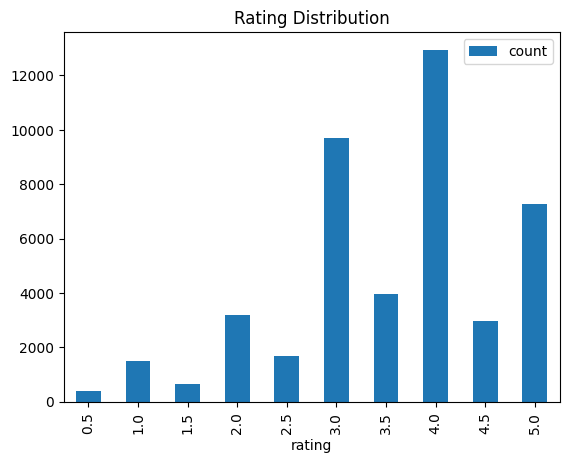

In [22]:
# Veri setinin istatistiksel özetini alıp görselleştirme
# Örneğin, rating dağılımı gibi
rating_distribution = cleaned_df.groupBy("rating").count().orderBy("rating")
rating_distribution.show()
rating_distribution.toPandas().plot(kind="bar", x="rating", y="count", title="Rating Distribution")


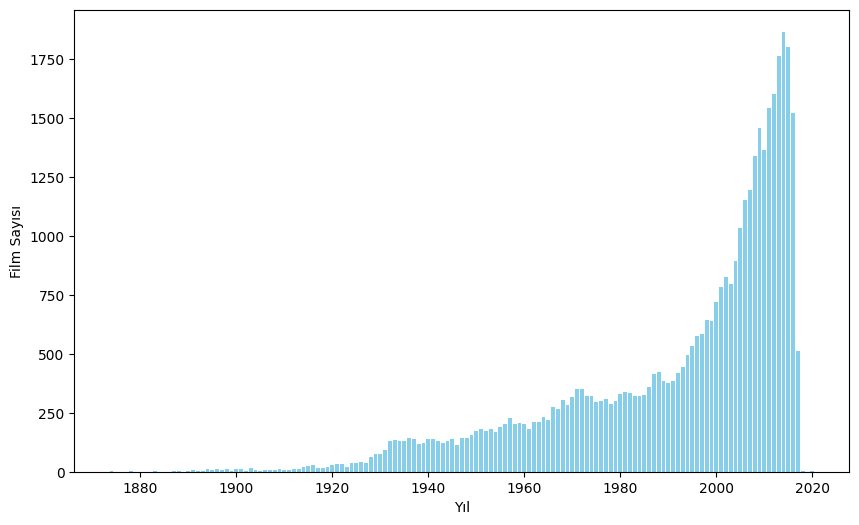

In [23]:
# 'release_date' sütununu 'date' veri türüne dönüştürme
movies_with_date = movies_metadata_df.withColumn("release_date", F.to_date("release_date"))

# 'release_date' sütunundan yıl bilgisini çıkarma ve 'release_year' sütununu oluşturma
movies_with_year = movies_with_date.withColumn("release_year", F.year("release_date"))

# Boş değerleri ve hatalı girişleri filtreleme
cleaned_movies_with_year = movies_with_year.filter((F.col("release_year").isNotNull()) & (F.col("release_year") > 0))

# Temizlenmiş DataFrame'i kullanarak histogram oluşturma
cleaned_movie_counts_per_year = cleaned_movies_with_year.groupBy("release_year").count()
cleaned_years = [row.release_year for row in cleaned_movie_counts_per_year.collect()]
cleaned_film_counts = [row["count"] for row in cleaned_movie_counts_per_year.collect()]

# Histogram oluşturma
plt.figure(figsize=(10, 6))
plt.bar(cleaned_years, cleaned_film_counts, color='skyblue')
plt.xlabel('Yıl')
plt.ylabel('Film Sayısı')
plt.show()



In [37]:

# Veriyi train ve test setlerine bölmek
train_df, test_df = cleaned_df.randomSplit([0.7, 0.3], seed=5001)

# ALS modeli oluşturma ve parametre ayarları
rank = 10  # Modelin içsel faktör sayısı
maxIter = 10  # Iterasyon sayısı
regParam = 0.01  # Düzenleme parametresi (regularization parameter)
seed = 5001  # Seed değeri

als = ALS(rank=rank, maxIter=maxIter, regParam=regParam, userCol="userId", itemCol="movieId", ratingCol="rating", coldStartStrategy="drop", seed=seed)
model = als.fit(train_df)  # train seti üzerinde modeli eğitme

# Test seti üzerinde tahminler yapma
predictions = model.transform(test_df)

# İlk 10 tahmini gösterme
predictions.select("userId", "movieId", "rating", "prediction").show(10)

# RMSE hesaplama
evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
rmse = evaluator.evaluate(predictions)
print("Root Mean Squared Error (RMSE) = ", rmse)

# MSE hesaplama
mse = evaluator.evaluate(predictions, {evaluator.metricName: "mse"})
print("Mean Squared Error (MSE) = ", mse)


+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|     3|   1580|   3.5| 3.7032263|
|    14|   3175|   5.0| 3.2135885|
|    15|    471|   3.0| 6.0286994|
|    15|   1580|   4.0| 2.6570082|
|    15|   1645|   3.0| 2.3449204|
|    15|   3175|   4.0| 2.6943154|
|    22|   1580|   4.0|  2.969387|
|    23|   1959|   2.5|   4.08596|
|    23|   6620|   3.5|  3.305661|
|    30|    471|   4.0| 3.6251793|
+------+-------+------+----------+
only showing top 10 rows

Root Mean Squared Error (RMSE) =  1.22505532101419
Mean Squared Error (MSE) =  1.50076053954518


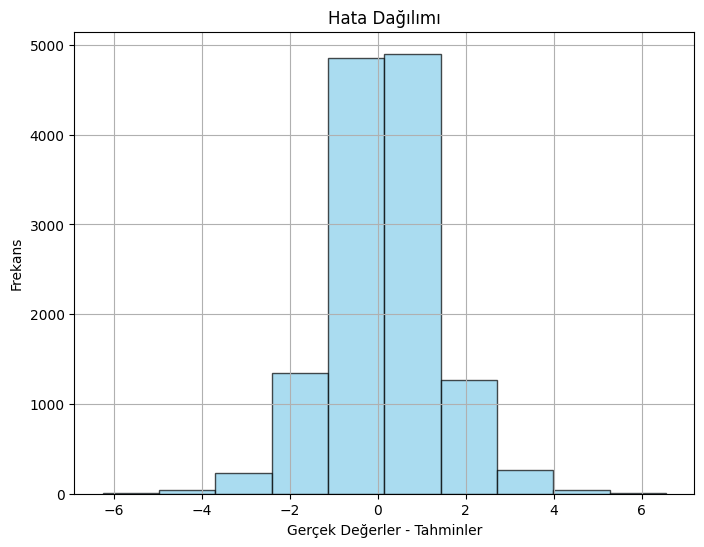

In [38]:
errors = predictions.select("rating", "prediction").rdd.map(lambda x: x[0] - x[1]).collect()

# Hata dağılımını gösteren bir histogram oluşturun
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Hata Dağılımı')
plt.xlabel('Gerçek Değerler - Tahminler')
plt.ylabel('Frekans')
plt.grid(True)
plt.show()

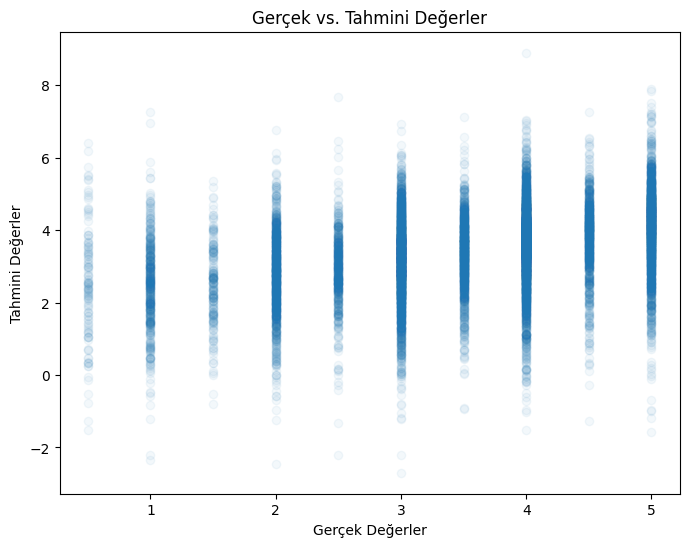

In [41]:
# Gerçek ve tahmini değerler
actual = predictions.select("rating").collect()
predicted = predictions.select("prediction").collect()

# Scatter plot oluştur
plt.figure(figsize=(8, 6))
plt.scatter(actual, predicted, alpha=0.05)
plt.title('Gerçek vs. Tahmini Değerler')
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmini Değerler')
plt.show()

In [33]:
# Veriyi train ve test setlerine bölmek
train_df, test_df = cleaned_df.randomSplit([0.7, 0.3], seed=5001)

# ALS modeli oluşturma ve parametre ayarları
rank = 10  # Modelin içsel faktör sayısı
maxIter = 20  # Iterasyon sayısı
regParam = 0.1  # Düzenleme parametresi (regularization parameter)
seed = 5001  # Seed değeri

als = ALS(rank=rank, maxIter=maxIter, regParam=regParam, userCol="userId", itemCol="movieId", ratingCol="rating", coldStartStrategy="drop", seed=seed)
model = als.fit(train_df)  # train seti üzerinde modeli eğitme

# Test seti üzerinde tahminler yapma
predictions = model.transform(test_df)

# İlk 10 tahmini gösterme
predictions.select("userId", "movieId", "rating", "prediction").show(10)

# RMSE hesaplama
evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
rmse = evaluator.evaluate(predictions)
print("Root Mean Squared Error (RMSE) = ", rmse)

# MSE hesaplama
mse = evaluator.evaluate(predictions, {evaluator.metricName: "mse"})
print("Mean Squared Error (MSE) = ", mse)




+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|     3|   1580|   3.5| 2.8368483|
|    14|   3175|   5.0| 1.9792044|
|    15|    471|   3.0|   3.73499|
|    15|   1580|   4.0| 3.0010588|
|    15|   1645|   3.0|   2.96644|
|    15|   3175|   4.0|  3.065268|
|    22|   1580|   4.0| 3.4617307|
|    23|   1959|   2.5| 3.8210166|
|    23|   6620|   3.5|  3.426311|
|    30|    471|   4.0| 3.8340354|
+------+-------+------+----------+
only showing top 10 rows

Root Mean Squared Error (RMSE) =  0.9454168063510177
Mean Squared Error (MSE) =  0.8938129377309577


In [34]:
# Veriyi train ve test setlerine bölmek
train_df, test_df = cleaned_df.randomSplit([0.7, 0.3], seed=5001)

# ALS modeli oluşturma ve parametre ayarları
rank = 10  # Modelin içsel faktör sayısı
maxIter = 10  # Iterasyon sayısı
regParam = 0.1  # Düzenleme parametresi (regularization parameter)
seed = 5001  # Seed değeri

als = ALS(rank=rank, maxIter=maxIter, regParam=regParam, userCol="userId", itemCol="movieId", ratingCol="rating", coldStartStrategy="drop", seed=seed)
model = als.fit(train_df)  # train seti üzerinde modeli eğitme

# Test seti üzerinde tahminler yapma
predictions = model.transform(test_df)

# İlk 10 tahmini gösterme
predictions.select("userId", "movieId", "rating", "prediction").show(10)

# RMSE hesaplama
evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
rmse = evaluator.evaluate(predictions)
print("Root Mean Squared Error (RMSE) = ", rmse)

# MSE hesaplama
mse = evaluator.evaluate(predictions, {evaluator.metricName: "mse"})
print("Mean Squared Error (MSE) = ", mse)

+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|     3|   1580|   3.5| 3.1019218|
|    14|   3175|   5.0| 2.1987584|
|    15|    471|   3.0| 4.1616726|
|    15|   1580|   4.0|  2.779143|
|    15|   1645|   3.0| 2.9011445|
|    15|   3175|   4.0| 3.0602086|
|    22|   1580|   4.0| 3.4427536|
|    23|   1959|   2.5|  3.776903|
|    23|   6620|   3.5| 3.3680906|
|    30|    471|   4.0|  3.629766|
+------+-------+------+----------+
only showing top 10 rows

Root Mean Squared Error (RMSE) =  0.9417290957776836
Mean Squared Error (MSE) =  0.8868536898342535


In [35]:
# Veriyi train ve test setlerine bölmek
train_df, test_df = cleaned_df.randomSplit([0.7, 0.3], seed=5001)

# ALS modeli oluşturma ve parametre ayarları
rank = 20  # Modelin içsel faktör sayısı
maxIter = 10  # Iterasyon sayısı
regParam = 0.1  # Düzenleme parametresi (regularization parameter)
seed = 5001  # Seed değeri

als = ALS(rank=rank, maxIter=maxIter, regParam=regParam, userCol="userId", itemCol="movieId", ratingCol="rating", coldStartStrategy="drop", seed=seed)
model = als.fit(train_df)  # train seti üzerinde modeli eğitme

# Test seti üzerinde tahminler yapma
predictions = model.transform(test_df)

# İlk 10 tahmini gösterme
predictions.select("userId", "movieId", "rating", "prediction").show(10)

# RMSE hesaplama
evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
rmse = evaluator.evaluate(predictions)
print("Root Mean Squared Error (RMSE) = ", rmse)

# MSE hesaplama
mse = evaluator.evaluate(predictions, {evaluator.metricName: "mse"})
print("Mean Squared Error (MSE) = ", mse)

+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|     3|   1580|   3.5|  3.111822|
|    14|   3175|   5.0| 2.1982462|
|    15|    471|   3.0| 3.3362532|
|    15|   1580|   4.0| 2.7856667|
|    15|   1645|   3.0| 2.9172313|
|    15|   3175|   4.0|  3.373632|
|    22|   1580|   4.0| 3.1889303|
|    23|   1959|   2.5| 3.5371847|
|    23|   6620|   3.5| 3.4645195|
|    30|    471|   4.0| 3.7088134|
+------+-------+------+----------+
only showing top 10 rows

Root Mean Squared Error (RMSE) =  0.9391203476285372
Mean Squared Error (MSE) =  0.8819470273299447


In [36]:
# Veriyi train ve test setlerine bölmek
train_df, test_df = cleaned_df.randomSplit([0.7, 0.3], seed=5001)

# ALS modeli oluşturma ve parametre ayarları
rank = 30  # Modelin içsel faktör sayısı
maxIter = 10  # Iterasyon sayısı
regParam = 0.1  # Düzenleme parametresi (regularization parameter)
seed = 5001  # Seed değeri

als = ALS(rank=rank, maxIter=maxIter, regParam=regParam, userCol="userId", itemCol="movieId", ratingCol="rating", coldStartStrategy="drop", seed=seed)
model = als.fit(train_df)  # train seti üzerinde modeli eğitme

# Test seti üzerinde tahminler yapma
predictions = model.transform(test_df)

# İlk 10 tahmini gösterme
predictions.select("userId", "movieId", "rating", "prediction").show(10)

# RMSE hesaplama
evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
rmse = evaluator.evaluate(predictions)
print("Root Mean Squared Error (RMSE) = ", rmse)

# MSE hesaplama
mse = evaluator.evaluate(predictions, {evaluator.metricName: "mse"})
print("Mean Squared Error (MSE) = ", mse)

+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|     3|   1580|   3.5| 2.9784868|
|    14|   3175|   5.0| 2.2222936|
|    15|    471|   3.0| 3.2708762|
|    15|   1580|   4.0|  2.710527|
|    15|   1645|   3.0|   3.03124|
|    15|   3175|   4.0| 3.0552762|
|    22|   1580|   4.0| 3.1940944|
|    23|   1959|   2.5| 3.8051927|
|    23|   6620|   3.5|  3.411983|
|    30|    471|   4.0|  3.572775|
+------+-------+------+----------+
only showing top 10 rows

Root Mean Squared Error (RMSE) =  0.9341356459235985
Mean Squared Error (MSE) =  0.8726094049850988


In [43]:
# Veriyi train ve test setlerine bölmek
train_df, test_df = cleaned_df.randomSplit([0.7, 0.3], seed=5001)

# ALS modeli oluşturma ve parametre ayarları
rank = 200  # Modelin içsel faktör sayısı
maxIter = 10  # Iterasyon sayısı
regParam = 0.1  # Düzenleme parametresi (regularization parameter)
seed = 5001  # Seed değeri

als = ALS(rank=rank, maxIter=maxIter, regParam=regParam, userCol="userId", itemCol="movieId", ratingCol="rating", coldStartStrategy="drop", seed=seed)
model = als.fit(train_df)  # train seti üzerinde modeli eğitme

# Test seti üzerinde tahminler yapma
predictions = model.transform(test_df)

# İlk 10 tahmini gösterme
predictions.select("userId", "movieId", "rating", "prediction").show(10)

# RMSE hesaplama
evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
rmse = evaluator.evaluate(predictions)
print("Root Mean Squared Error (RMSE) = ", rmse)

# MSE hesaplama
mse = evaluator.evaluate(predictions, {evaluator.metricName: "mse"})
print("Mean Squared Error (MSE) = ", mse)

+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|     3|   1580|   3.5| 3.1821532|
|    14|   3175|   5.0|  2.244416|
|    15|    471|   3.0|  3.197428|
|    15|   1580|   4.0|  2.838958|
|    15|   1645|   3.0| 2.8068829|
|    15|   3175|   4.0| 3.1569216|
|    22|   1580|   4.0| 3.2784526|
|    23|   1959|   2.5| 3.7653701|
|    23|   6620|   3.5| 3.4730659|
|    30|    471|   4.0| 3.7975075|
+------+-------+------+----------+
only showing top 10 rows

Root Mean Squared Error (RMSE) =  0.9301100690984476
Mean Squared Error (MSE) =  0.865104740638319


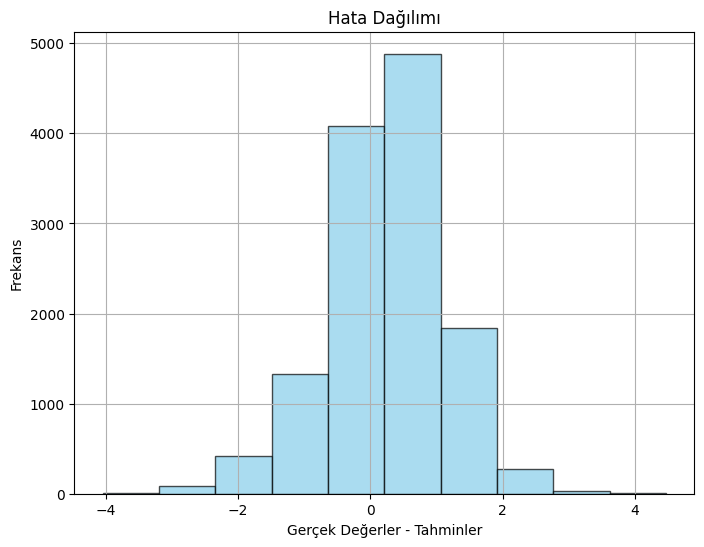

In [44]:
errors = predictions.select("rating", "prediction").rdd.map(lambda x: x[0] - x[1]).collect()

# Hata dağılımını gösteren bir histogram oluşturun
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Hata Dağılımı')
plt.xlabel('Gerçek Değerler - Tahminler')
plt.ylabel('Frekans')
plt.grid(True)
plt.show()

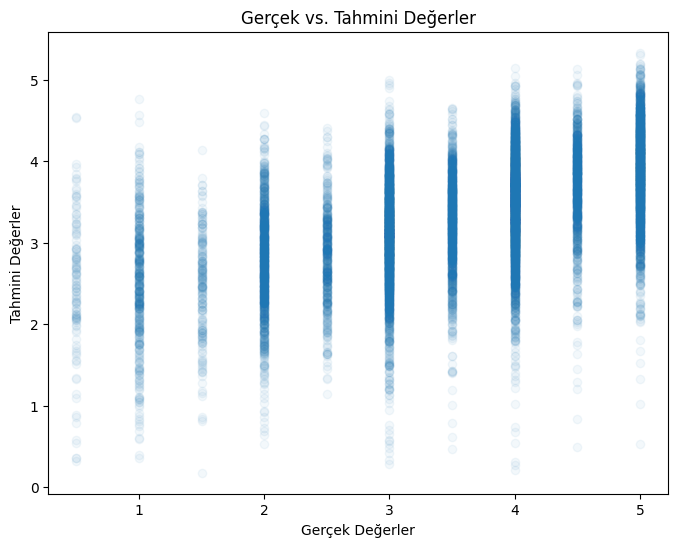

In [45]:
# Gerçek ve tahmini değerler
actual = predictions.select("rating").collect()
predicted = predictions.select("prediction").collect()

# Scatter plot oluştur
plt.figure(figsize=(8, 6))
plt.scatter(actual, predicted, alpha=0.05)
plt.title('Gerçek vs. Tahmini Değerler')
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmini Değerler')
plt.show()

In [47]:
# ALS modeli ile elde edilen faktörler
item_factors = model.itemFactors

# DataFrame'e çevirme ve sütun isimlerini düzenleme
item_factors_df = item_factors.select("id", "features") \
                               .withColumnRenamed("id", "movieId") \
                               .withColumnRenamed("features", "factors")

# Gerçek veri seti ile birleştirme
joined_df = cleaned_df.join(item_factors_df, cleaned_df.movieId == item_factors_df.movieId)

# Bir veri kümesindeki movieId sütununu kaldırma
joined_df = joined_df.drop(cleaned_df.movieId)

# Temsil vektörünü almak için UDF (User Defined Function) tanımlama
@F.udf(returnType=VectorUDT())
def get_factors(factors):
    return Vectors.dense(factors)

# Temsil vektörünü almak için UDF'i kullanma
joined_df = joined_df.withColumn("representation", get_factors("factors"))

# İlk 10 tahmini gösterme
joined_df.show(10)

+------+------+--------------------+-------+--------------------+--------------------+
|userId|rating|               title|movieId|             factors|      representation|
+------+------+--------------------+-------+--------------------+--------------------+
|     3|   3.5|            Released|   1580|[0.39591557, -0.0...|[0.39591556787490...|
|     4|   5.0|            Released|   1580|[0.39591557, -0.0...|[0.39591556787490...|
|    14|   5.0|        Barry Lyndon|   3175|[0.36061552, -0.1...|[0.36061552166938...|
|    15|   3.0|             Bandyta|    471|[0.2709632, -0.07...|[0.27096319198608...|
|    15|   2.0|         Whale Rider|   1088|[0.24020639, -0.0...|[0.24020639061927...|
|    15|   4.0|            Released|   1580|[0.39591557, -0.0...|[0.39591556787490...|
|    15|   3.0|      A Time to Kill|   1645|[0.13366556, -0.2...|[0.13366556167602...|
|    15|   4.0|        Barry Lyndon|   3175|[0.36061552, -0.1...|[0.36061552166938...|
|    15|   1.5|[{'iso_3166_1': '...|   6620

In [48]:
# Cosine similarity fonksiyonu
def cosine_similarity(vector1, vector2):
    dot_product = np.dot(vector1, vector2)
    norm_vector1 = np.linalg.norm(vector1)
    norm_vector2 = np.linalg.norm(vector2)
    similarity = dot_product / (norm_vector1 * norm_vector2)
    return similarity

# Spark DataFrame'deki sütunları Pandas DataFrame'e dönüştürme
item_factors_pd = item_factors_df.select("movieId", "factors").toPandas()

# Pandas DataFrame'deki sütunları NumPy dizilerine dönüştürme
item_factors_np = np.array(item_factors_pd["factors"].tolist())

# Her bir film için diğer filmlerle olan benzerlikleri hesaplama
movie_similarity_matrix = np.zeros((len(item_factors_np), len(item_factors_np)))
for i in range(len(item_factors_np)):
    for j in range(len(item_factors_np)):
        movie_similarity_matrix[i][j] = cosine_similarity(item_factors_np[i], item_factors_np[j])

# Benzerlik matrisini gösterme
print(movie_similarity_matrix)


[[1.         0.4923288  0.51912419 ... 0.6745132  0.46251238 0.33726921]
 [0.4923288  1.         0.56521875 ... 0.80398692 0.67917857 0.7041785 ]
 [0.51912419 0.56521875 1.         ... 0.66864574 0.48956576 0.60361462]
 ...
 [0.6745132  0.80398692 0.66864574 ... 1.         0.70719786 0.6210521 ]
 [0.46251238 0.67917857 0.48956576 ... 0.70719786 1.         0.54205007]
 [0.33726921 0.7041785  0.60361462 ... 0.6210521  0.54205007 1.        ]]


In [49]:
# Belirli bir film için kullanıcı tahminlerini alın
movie_id = 3175  # Örnek bir film ID'si
user_predictions = joined_df.filter(joined_df["movieId"] == movie_id)

# Kullanıcı tahminlerini, tahmin sırasına göre azalan şekilde sıralayın
sorted_user_predictions = user_predictions.orderBy(col("rating").desc())

# En çok beğenecek 10 kullanıcıyı seçin
top_10_users = sorted_user_predictions.select("userId", "title").limit(10)

# Sonucu gösterme
top_10_users.show()



+------+------------+
|userId|       title|
+------+------------+
|    14|Barry Lyndon|
|   125|Barry Lyndon|
|   346|Barry Lyndon|
|   401|Barry Lyndon|
|   407|Barry Lyndon|
|   564|Barry Lyndon|
|   575|Barry Lyndon|
|   577|Barry Lyndon|
|   626|Barry Lyndon|
|   134|Barry Lyndon|
+------+------------+



In [50]:
predictions.printSchema()


root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- title: string (nullable = true)
 |-- prediction: float (nullable = false)



In [51]:
big_rating_df = spark.read.csv("C:/spark/bin/ratings.csv", header=True, inferSchema=True)

In [52]:
# Büyük puanlama veri kümesini movies_metadata_df ile birleştirme
merged_df2 = big_rating_df.join(movies_metadata_df, big_rating_df.movieId == movies_metadata_df.id, "left_outer")

In [53]:
# Sadece gerekli sütunları seçme
selected_merged_df = merged_df2.select("userId", "movieId", "rating","title")

In [54]:
#Burada satır sayımızı öğrenicez yana datamızın büyüklüğü
row_count = selected_merged_df.count()
print("Veri kümesindeki satır sayısı:", row_count)

Veri kümesindeki satır sayısı: 26025358


In [50]:
# 'rating' sütununu kullanarak ortalama değeri hesapla
ortalama_rating2 = merged_df2.select("rating").agg(F.avg("rating").alias("ortalama_rating"))

# Sonucu göster
ortalama_rating2.show()

+------------------+
|   ortalama_rating|
+------------------+
|3.5280907182909838|
+------------------+



In [51]:
#3.543608255669773 önceki küçük veri setimizin mean burada büyük veri setiyle karşılaştırdık

In [55]:
selected_merged_df.select([F.count(F.when(F.isnull(c), c)).alias(c) for c in selected_merged_df.columns]).show()


+------+-------+------+--------+
|userId|movieId|rating|   title|
+------+-------+------+--------+
|     0|      0|     0|14777242|
+------+-------+------+--------+



In [56]:
selected_merged_df = selected_merged_df.dropna()


In [57]:
selected_merged_df.show(5)

+------+-------+------+--------------------+
|userId|movieId|rating|               title|
+------+-------+------+--------------------+
|     1|    110|   1.0|   Three Colors: Red|
|     1|    147|   4.5|       The 400 Blows|
|     1|    858|   5.0|Sleepless in Seattle|
|     1|   1246|   5.0|        Rocky Balboa|
|     1|   1968|   4.0|       Fools Rush In|
+------+-------+------+--------------------+
only showing top 5 rows



In [55]:
row_count2 = selected_merged_df.count()
print("Veri kümesindeki satır sayısı:", row_count2)

Veri kümesindeki satır sayısı: 11248116


In [58]:
#10 milyondan fazla satır olduğundan rank daha fazla arttıramadık ram sorunu yüzünden spark çalışmaz hale geliyor.
# Veriyi train ve test setlerine bölmek
train_df, test_df = selected_merged_df.randomSplit([0.7, 0.3], seed=5001)

# ALS modeli oluşturma ve parametre ayarları
rank = 10  # Modelin içsel faktör sayısı
maxIter = 10  # Iterasyon sayısı
regParam = 0.1  # Düzenleme parametresi (regularization parameter)
seed = 5001  # Seed değeri

als = ALS(rank=rank, maxIter=maxIter, regParam=regParam, userCol="userId", itemCol="movieId", ratingCol="rating", coldStartStrategy="drop", seed=seed)
model = als.fit(train_df)  # train seti üzerinde modeli eğitme

# Test seti üzerinde tahminler yapma
predictions = model.transform(test_df)

# İlk 10 tahmini gösterme
predictions.select("userId", "movieId", "rating", "prediction").show(10)

# RMSE hesaplama
evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
rmse = evaluator.evaluate(predictions)
print("Root Mean Squared Error (RMSE) = ", rmse)

# MSE hesaplama
mse = evaluator.evaluate(predictions, {evaluator.metricName: "mse"})
print("Mean Squared Error (MSE) = ", mse)



+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|    12|     17|   4.0| 4.0158973|
|    12|     73|   2.0| 3.7099698|
|    12|    150|   5.0| 3.1913748|
|    12|    162|   4.0|   4.25963|
|    12|    175|   5.0| 3.6983047|
|    12|    176|   4.0|  3.932478|
|    12|    273|   3.0| 2.7040763|
|    12|    293|   4.0| 3.9185698|
|    12|    322|   5.0|  3.678667|
|    12|    441|   4.0| 3.6718676|
+------+-------+------+----------+
only showing top 10 rows

Root Mean Squared Error (RMSE) =  0.8376253523943266
Mean Squared Error (MSE) =  0.7016162309737198


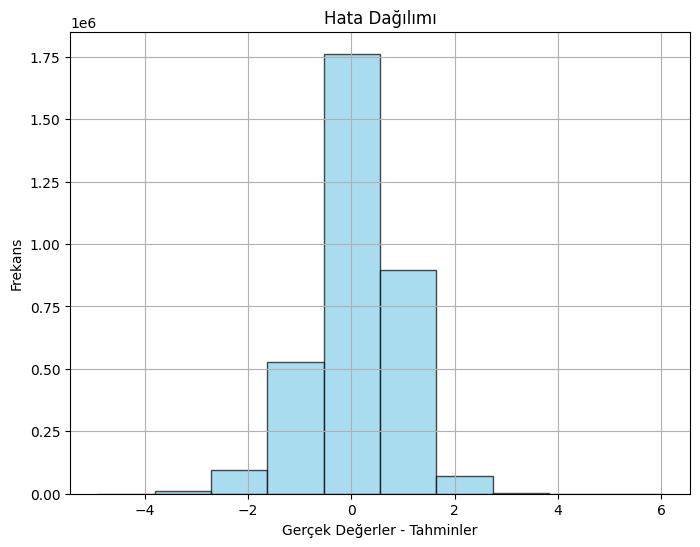

In [59]:
errors = predictions.select("rating", "prediction").rdd.map(lambda x: x[0] - x[1]).collect()

# Hata dağılımını gösteren bir histogram oluşturun
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Hata Dağılımı')
plt.xlabel('Gerçek Değerler - Tahminler')
plt.ylabel('Frekans')
plt.grid(True)
plt.show()

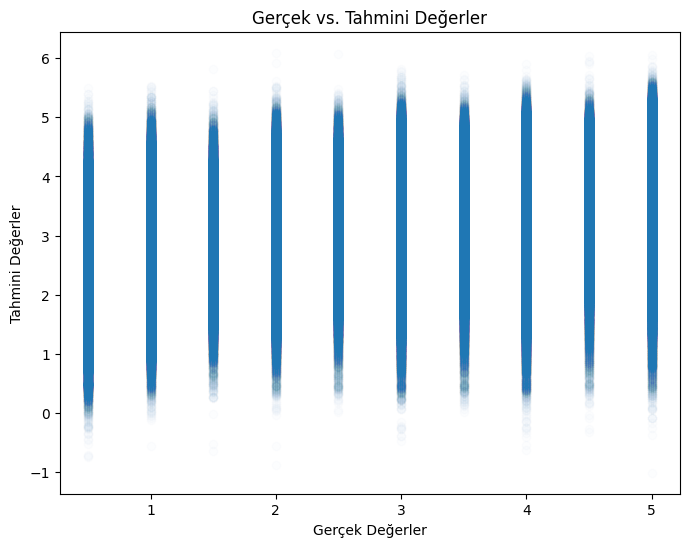

In [61]:
# Gerçek ve tahmini değerler
actual = predictions.select("rating").collect()
predicted = predictions.select("prediction").collect()

# Scatter plot oluştur
plt.figure(figsize=(8, 6))
plt.scatter(actual, predicted, alpha=0.01)
plt.title('Gerçek vs. Tahmini Değerler')
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmini Değerler')
plt.show()

In [58]:
# DataFrame'i RDD'ye dönüştür
rating_rdd = merged_df2.select("rating").rdd
# RDD üzerinde reduce işlemi kullanarak ortalama değeri hesapla
ortalama_rating = rating_rdd.map(lambda row: row[0]).reduce(lambda x, y: x + y) / rating_rdd.count()
# Sonucu göster
print("Ortalama Rating:", ortalama_rating) #Bu örnek reduce kullandığımız yer

Ortalama Rating: 3.5280907182909838


In [59]:
#mapping zaten bizim movieId yer göre iki dataframe arasında eşleme yaparken kullandık

In [3]:
#VirtualMachine içinde çalıştırılmıştır
import socket
host_name=socket.gethostname()
host_ip=socket.gethostbyname(host_name)

print("Host Name:",host_name)
print("Host Ip:",host_ip)

Host Name: Eren-VM
Host Ip: 10.0.2.15
